In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("adult_dataset_modified.csv")

df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income,employee_id
0,90.0,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,999999,4356,40,United-States,<=50K,EMP00000
1,82.0,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,250,United-States,<=50K,EMP00001
2,150.0,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K,EMP00002
3,54.0,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K,EMP00003
4,41.0,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K,EMP00004


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             32431 non-null  float64
 1   workclass       32481 non-null  str    
 2   fnlwgt          32581 non-null  int64  
 3   education       32581 non-null  str    
 4   education.num   32581 non-null  int64  
 5   marital.status  32581 non-null  str    
 6   occupation      32461 non-null  str    
 7   relationship    32581 non-null  str    
 8   race            32581 non-null  str    
 9   sex             32581 non-null  str    
 10  capital.gain    32581 non-null  int64  
 11  capital.loss    32581 non-null  int64  
 12  hours.per.week  32581 non-null  int64  
 13  native.country  32581 non-null  str    
 14  income          32581 non-null  str    
 15  employee_id     32581 non-null  str    
dtypes: float64(1), int64(5), str(10)
memory usage: 4.0 MB


Berdasarkan hasil df.info(), ditemukan adanya missing value pada kolom age, workclass, dan occupation. Dataset didominasi oleh kolom bertipe object yang merupakan data kategorikal, sedangkan kolom employee_id memiliki kardinalitas tinggi. Oleh karena itu, diperlukan proses pembersihan data berupa penanganan missing value, pengecekan data duplikat, outlier, dan validasi tipe data sebelum dilakukan analisis lebih lanjut.

In [7]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32431.000000,3.258100e+04,32581.000000,32581.000000,32581.000000,32581.000000
mean,38.597761,1.897691e+05,10.080507,1138.596728,88.440441,40.451060
std,13.678002,1.055380e+05,2.572735,10759.281139,408.333071,12.454008
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370440e+05,12.000000,0.000000,0.000000,45.000000
max,150.000000,1.484705e+06,16.000000,999999.000000,4356.000000,250.000000


Berdasarkan hasil statistik deskriptif, ditemukan beberapa hal penting, yaitu:

- Kolom **age** memiliki jumlah data sebanyak 32.431 dari total 32.581 data, sehingga terdapat missing value yang perlu dilakukan penanganan. Nilai maksimum pada age sebesar **150 tahun** mengindikasikan adanya kemungkinan outlier atau kesalahan input data yang perlu dianalisis lebih lanjut menggunakan boxplot pada tahap analisis univariat.
- Kolom **fnlwgt** memiliki rentang nilai yang cukup besar dengan nilai maksimum mencapai **1.484.705**, sehingga perlu dilakukan pengecekan terhadap distribusi data dan kemungkinan adanya nilai ekstrem.
- Kolom **education.num** memiliki nilai rata-rata sebesar **10,08** dengan rentang nilai **1–16**, yang menunjukkan variasi tingkat pendidikan pada data.
- Kolom **capital.gain** dan **capital.loss** memiliki sebagian besar nilai **0**, terlihat dari nilai kuartil yang bernilai 0. Hal ini menunjukkan bahwa mayoritas individu tidak memiliki keuntungan maupun kerugian modal.
- Kolom **hours.per.week** memiliki rata-rata **40,45 jam** per minggu. Nilai maksimum sebesar **250 jam** mengindikasikan adanya kemungkinan outlier yang perlu dianalisis lebih lanjut.

In [8]:
df.describe(include='object')

C:\Users\Azzam\AppData\Local\Temp\ipykernel_9288\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,workclass,education,marital.status,occupation,relationship,race,sex,native.country,income,employee_id
count,32481,32581,32581,32461,32581,32581,32581,32581,32581,32581
unique,9,16,7,15,6,5,2,42,2,32571
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K,EMP00000
freq,22641,10509,14980,4123,13197,27835,21800,29189,24734,2


Kolom workclass didominasi oleh kategori Private sebanyak 22.641 data dari total 32.481 data.
Kolom education paling banyak memiliki kategori HS-grad dengan jumlah 10.509 data, menunjukkan mayoritas individu memiliki tingkat pendidikan SMA.
Kolom marital.status didominasi oleh kategori Married-civ-spouse sebanyak 14.980 data.
Kolom occupation paling banyak berasal dari kategori Prof-specialty dengan jumlah 4.123 data.
Kolom relationship didominasi oleh kategori Husband sebanyak 13.197 data.
Kolom race mayoritas berada pada kategori White sebanyak 27.835 data.
Kolom sex didominasi oleh kategori Male sebanyak 21.800 data.
Kolom native.country sebagian besar berasal dari United-States sebanyak 29.189 data.
Kolom income menunjukkan mayoritas individu memiliki pendapatan <=50K dengan jumlah 24.734 data.
Kolom employee_id memiliki nilai unik sebanyak 32.571 dari total 32.581 data, sehingga terdapat beberapa ID yang duplikat dan perlu dilakukan pengecekan lebih lanjut.

In [9]:
#Cek Kualitas Data
df.isnull().sum()

age               150
workclass         100
fnlwgt              0
education           0
education.num       0
marital.status      0
occupation        120
relationship        0
race                0
sex                 0
capital.gain        0
capital.loss        0
hours.per.week      0
native.country      0
income              0
employee_id         0
dtype: int64

Berdasarkan hasil pengecekan missing value menggunakan isnull().sum(), ditemukan bahwa terdapat data kosong pada tiga kolom, yaitu age sebanyak 150 data, workclass sebanyak 100 data, dan occupation sebanyak 120 data. Kolom lainnya tidak memiliki missing value, sehingga penanganan data kosong hanya perlu dilakukan pada ketiga kolom tersebut sebelum proses analisis lebih lanjut.

In [10]:
#Cek Kualitas Data
df.duplicated().sum()

np.int64(10)

Hasil pemeriksaan menunjukkan terdapat 10 baris data yang terduplikasi. Data duplikat dapat menyebabkan suatu informasi dihitung lebih dari satu kali sehingga berpotensi menghasilkan analisis yang bias dan memengaruhi performa model Machine Learning.

In [11]:
#penggunaan median memperbaiki miss value
df['age'] = df['age'].fillna(df['age'].median())

age merupakan data numerik.
Median lebih tahan terhadap outlier dibanding mean.
Pada data age terdapat kemungkinan outlier (nilai maksimum 150), sehingga median lebih tepat digunakan.

In [12]:
#penggunaan modus memperbaiki miss value
df['workclass'] = df['workclass'].fillna(df['workclass'].mode()[0])

df['occupation'] = df['occupation'].fillna(df['occupation'].mode()[0])

workclass dan occupation merupakan data kategorikal.
Modus digunakan karena dapat mempertahankan kategori yang paling sering muncul pada dataset.

In [13]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
employee_id       0
dtype: int64

Berdasarkan hasil pengecekan missing value, ditemukan data kosong pada kolom age, workclass, dan occupation. Penanganan missing value pada kolom age dilakukan menggunakan metode median karena data numerik dan terdapat indikasi outlier. Sedangkan kolom workclass dan occupation menggunakan metode modus karena merupakan data kategorikal, sehingga kategori yang paling sering muncul dapat digunakan sebagai pengganti nilai kosong.

In [14]:
#Menghapus Data Duplikat
df = df.drop_duplicates()

In [15]:
df.duplicated().sum()

np.int64(0)

Sebanyak 10 baris data duplikat berhasil diidentifikasi. Setelah dilakukan penghapusan menggunakan drop_duplicates(), jumlah data duplikat menjadi 0, sehingga setiap baris pada dataset telah bersifat unik dan siap untuk proses pembersihan data berikutnya.

In [16]:
df.dtypes

age               float64
workclass             str
fnlwgt              int64
education             str
education.num       int64
marital.status        str
occupation            str
relationship          str
race                  str
sex                   str
capital.gain        int64
capital.loss        int64
hours.per.week      int64
native.country        str
income                str
employee_id           str
dtype: object

In [17]:
## Perbaikan Tipe Data Kategorikal
categorical_cols = ['workclass', 'education', 'marital.status',
                    'occupation', 'relationship', 'race',
                    'sex', 'native.country', 'income']

df[categorical_cols] = df[categorical_cols].astype('category')

In [18]:
df.dtypes

age                float64
workclass         category
fnlwgt               int64
education         category
education.num        int64
marital.status    category
occupation        category
relationship      category
race              category
sex               category
capital.gain         int64
capital.loss         int64
hours.per.week       int64
native.country    category
income            category
employee_id            str
dtype: object

Berdasarkan hasil pengecekan tipe data menggunakan df.dtypes, sebagian besar kolom sudah memiliki tipe data yang sesuai dengan karakteristik datanya. Kolom numerik seperti **age, fnlwgt, education.num, capital.gain, capital.loss, dan hours.per.week** memiliki tipe data numerik (int64/float64), sedangkan kolom kategorikal seperti **workclass, education, marital.status, occupation, relationship, race, sex, native.country, income, dan employee_id** memiliki tipe data object.

Untuk meningkatkan efisiensi penyimpanan dan memperjelas bahwa kolom tersebut merupakan data kategorikal, kolom dengan tipe object yang bersifat kategori dikonversi menjadi tipe category.

In [19]:
numeric_cols = ['age', 'fnlwgt', 'education.num',
                'capital.gain', 'capital.loss',
                'hours.per.week']

df[numeric_cols].describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32571.000000,3.257100e+04,32571.000000,32571.000000,32571.000000,32571.000000
mean,38.581622,1.897737e+05,10.080777,1108.244174,87.277026,40.444598
std,13.627243,1.055390e+05,2.572573,9228.392659,402.901257,12.400663
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178300e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783700e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370475e+05,12.000000,0.000000,0.000000,45.000000
max,150.000000,1.484705e+06,16.000000,999999.000000,4356.000000,250.000000


Berdasarkan hasil statistik deskriptif, jumlah data pada setiap kolom numerik sebanyak 32.571 observasi. Rata-rata usia responden adalah 38,58 tahun dengan rentang usia 17 hingga 150 tahun, sehingga terdapat indikasi nilai ekstrem yang perlu diperiksa lebih lanjut melalui boxplot.

Kolom fnlwgtmemiliki rentang nilai yang cukup besar, yaitu dari12.285 hingga 1.484.705, yang menunjukkan variasi data yang tinggi. Sementara itu, education.num memiliki rentang nilai 1–16 dengan rata-rata 10,08, yang menunjukkan variasi tingkat pendidikan pada dataset.

Kolom capital.gain dan capital.loss memiliki nilai median sebesar 0, yang menunjukkan bahwa sebagian besar individu tidak memiliki keuntungan maupun kerugian modal. Namun, nilai maksimum pada capital.gain mencapai 999.999 dan capital.loss mencapai 4.356, sehingga terdapat indikasi adanya outlier.

Pada kolom hours.per.week, rata-rata jam kerja adalah 40,44 jam per minggu dengan nilai maksimum 250 jam, yang juga mengindikasikan adanya kemungkinan nilai ekstrem. Oleh karena itu, analisis selanjutnya dilakukan menggunakan histogram dan boxplot untuk melihat distribusi data serta mendeteksi keberadaan outlier.

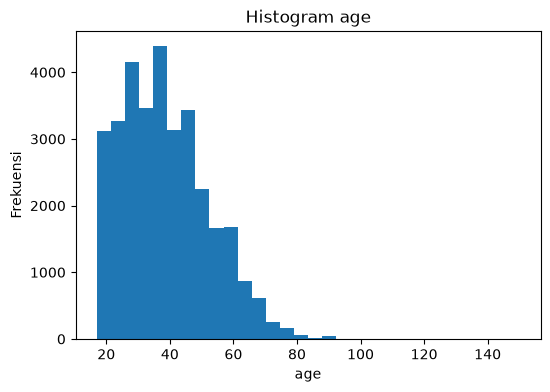

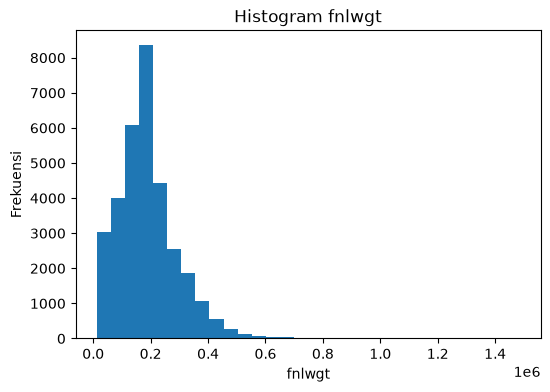

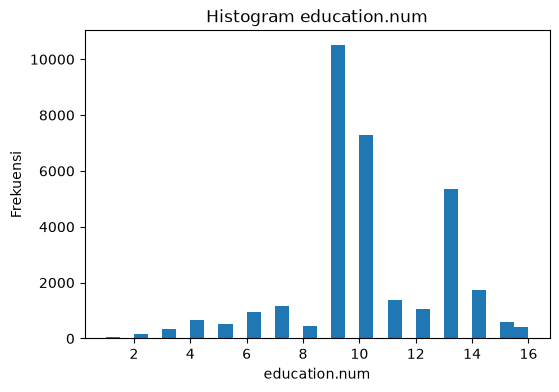

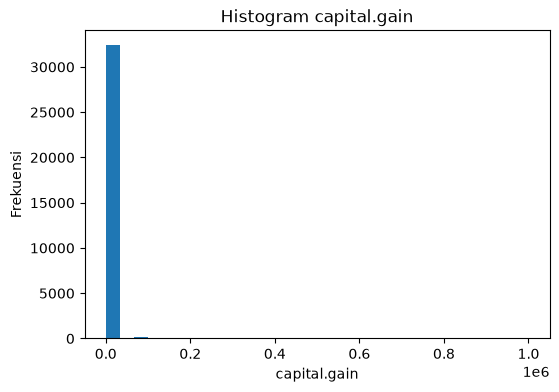

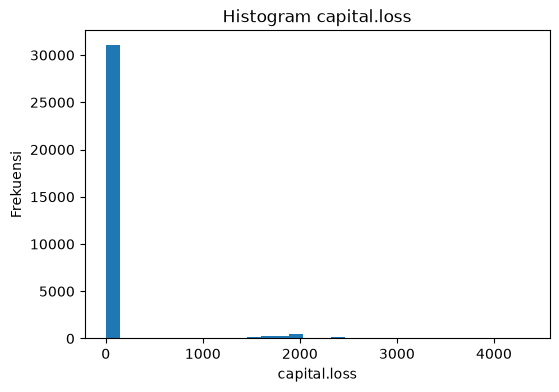

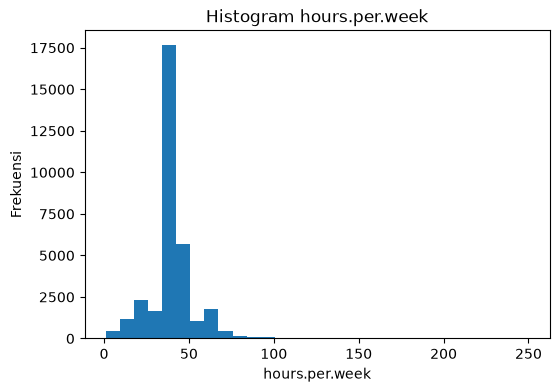

In [20]:
import matplotlib.pyplot as plt

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=30)
    plt.title(f'Histogram {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.show()

Berdasarkan visualisasi histogram pada setiap kolom numerik, diperoleh beberapa karakteristik distribusi data sebagai berikut.

Age memiliki distribusi yang cenderung miring ke kanan (right skew). Sebagian besar responden berusia antara 20–50 tahun, sedangkan usia yang lebih tinggi memiliki frekuensi yang semakin sedikit.
- Fnlwgt juga menunjukkan distribusi right skew , di mana sebagian besar data terkonsentrasi pada nilai yang relatif rendah dengan beberapa nilai yang sangat besar.
- Education.num merupakan variabel diskrit sehingga histogram menunjukkan beberapa puncak pada tingkat pendidikan tertentu. Sebagian besar data berada pada nilai 9–13.
- Capital.gain memiliki distribusi yang sangat miring ke kanan (highly right skew) karena hampir seluruh observasi bernilai 0, sedangkan hanya sebagian kecil memiliki nilai yang tinggi.
- Capital.loss juga menunjukkan pola yang sama dengan capital.gain, yaitu mayoritas bernilai 0 dengan sedikit observasi yang memiliki nilai di atas 0 sehingga distribusinya sangat right skew.
- Hours.per.week memiliki distribusi yang terkonsentrasi pada 40 jam kerja per minggu, yang menunjukkan sebagian besar individu bekerja dalam jam kerja normal. Namun, terdapat beberapa nilai yang jauh lebih tinggi sehingga distribusi sedikit miring ke kanan.

Secara keseluruhan, sebagian besar variabel numerik pada dataset tidak berdistribusi normal dan cenderung memiliki distribusi
positively skewed (right skew). Temuan ini akan diperkuat melalui analisis boxplot untuk mengidentifikasi keberadaan outlier pada masing-masing variabel.

C:\Users\Azzam\AppData\Local\Temp\ipykernel_9288\4205242096.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


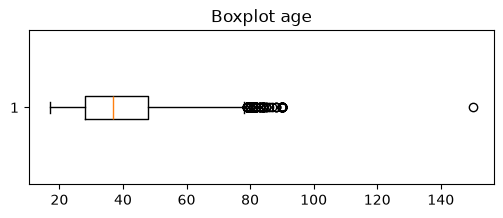

C:\Users\Azzam\AppData\Local\Temp\ipykernel_9288\4205242096.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


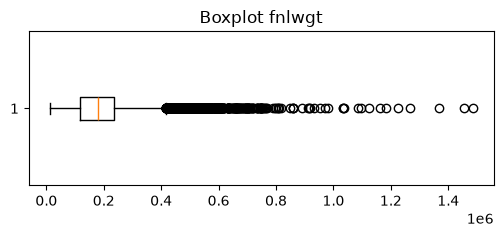

C:\Users\Azzam\AppData\Local\Temp\ipykernel_9288\4205242096.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


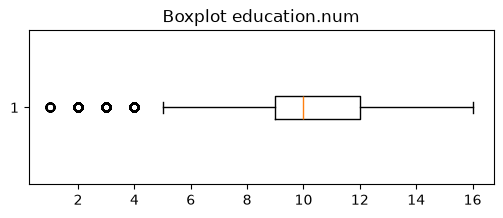

C:\Users\Azzam\AppData\Local\Temp\ipykernel_9288\4205242096.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


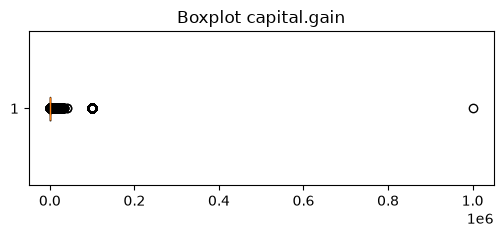

C:\Users\Azzam\AppData\Local\Temp\ipykernel_9288\4205242096.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


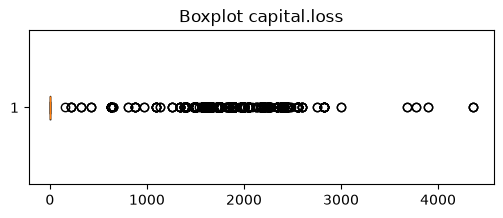

C:\Users\Azzam\AppData\Local\Temp\ipykernel_9288\4205242096.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


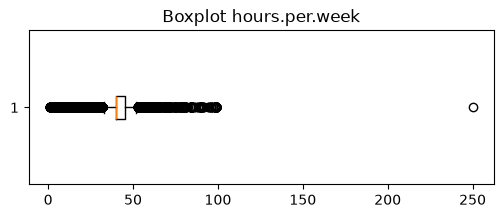

In [21]:
for col in numeric_cols:
    plt.figure(figsize=(6,2))
    plt.boxplot(df[col], vert=False)
    plt.title(f'Boxplot {col}')
    plt.show()


Berdasarkan visualisasi boxplot pada setiap kolom numerik, diperoleh beberapa temuan sebagai berikut.

- Age menunjukkan adanya beberapa outlier pada usia yang sangat tinggi, termasuk nilai maksimum sebesar 150 tahun yang diduga merupakan nilai ekstrem atau kesalahan pencatatan data.
- Fnlwgt memiliki banyak outlier pada nilai yang tinggi, menunjukkan bahwa terdapat sejumlah observasi dengan nilai yang jauh lebih besar dibandingkan mayoritas data.
- Education.num hanya memiliki sedikit outlier pada nilai pendidikan yang rendah, sedangkan sebagian besar data berada pada rentang 9–12.
- Capital.gain memiliki jumlah outlier yang cukup banyak. Mayoritas data bernilai 0, namun terdapat beberapa observasi dengan nilai yang sangat tinggi hingga 999.999, sehingga distribusinya sangat tidak merata.
- Capital.loss juga menunjukkan banyak outlier. Sebagian besar data bernilai 0, sedangkan sebagian kecil memiliki nilai yang jauh lebih tinggi.
- Hours.per.week memiliki beberapa outlier pada jam kerja yang sangat tinggi, termasuk nilai maksimum sebesar 250 jam per minggu, yang mengindikasikan adanya nilai ekstrem.

Secara keseluruhan, hampir seluruh variabel numerik memiliki outlier, terutama pada fnlwgt, capital.gain, capital.loss, dan hours.per.week. Keberadaan outlier ini sejalan dengan hasil histogram yang menunjukkan distribusi data cenderung miring ke kanan (right skew), sehingga analisis skewness dilakukan untuk mengukur tingkat kemencengan distribusi secara kuantitatif.

In [22]:
df[numeric_cols].skew()

age                0.576240
fnlwgt             1.447074
education.num     -0.311575
capital.gain      45.057534
capital.loss       4.595432
hours.per.week     0.371096
dtype: float64

## Distribusi Frekuensi Kolom Kategorikal

Distribusi frekuensi digunakan untuk mengetahui jumlah kemunculan setiap kategori pada masing-masing variabel kategorikal.

In [23]:
categorical_cols = ['workclass','education','marital.status',
                    'occupation','relationship','race',
                    'sex','native.country','income']

for col in categorical_cols:
    print("="*50)
    print(col)
    print(df[col].value_counts())

workclass
workclass
Private             22735
Self-emp-not-inc     2534
Local-gov            2086
?                    1829
State-gov            1294
Self-emp-inc         1114
Federal-gov           958
Without-pay            14
Never-worked            7
Name: count, dtype: int64
education
education
HS-grad         10505
Some-college     7293
Bachelors        5357
Masters          1724
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              434
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype: int64
marital.status
marital.status
Married-civ-spouse       14980
Never-married            10687
Divorced                  4444
Separated                 1026
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64
occupation
occupation
Prof-specialty       4240
C

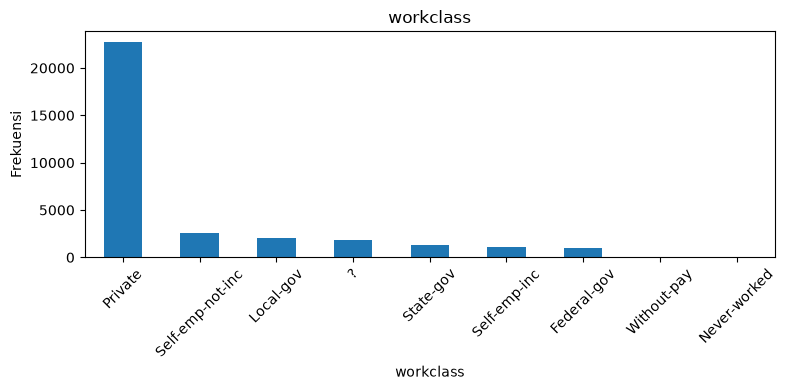

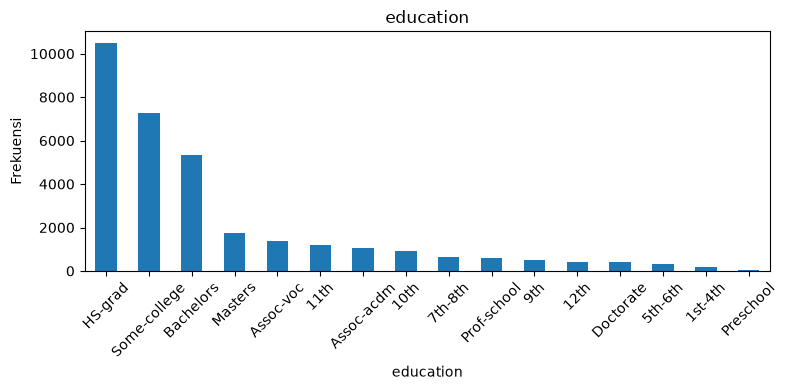

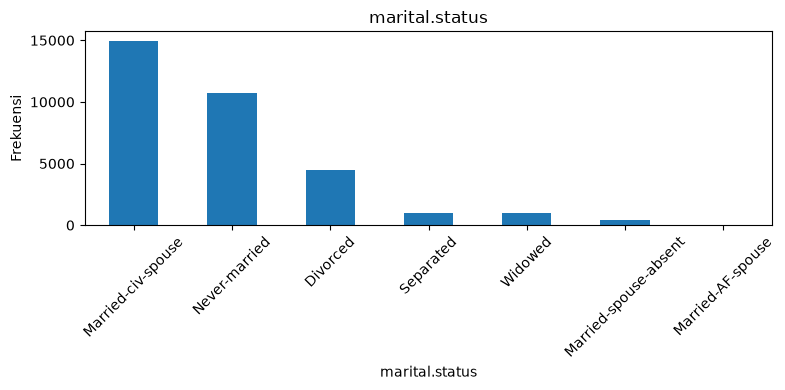

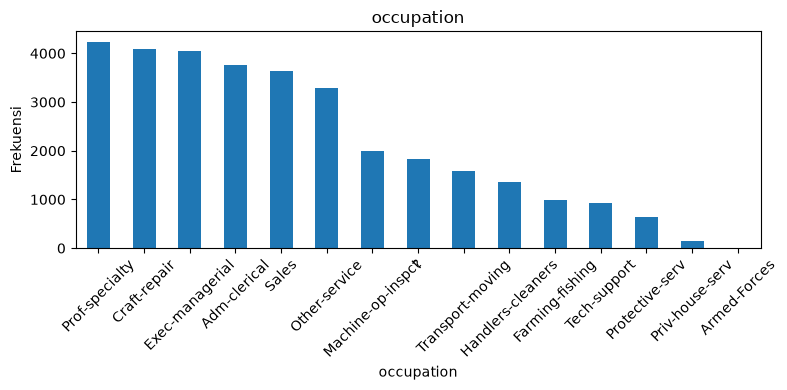

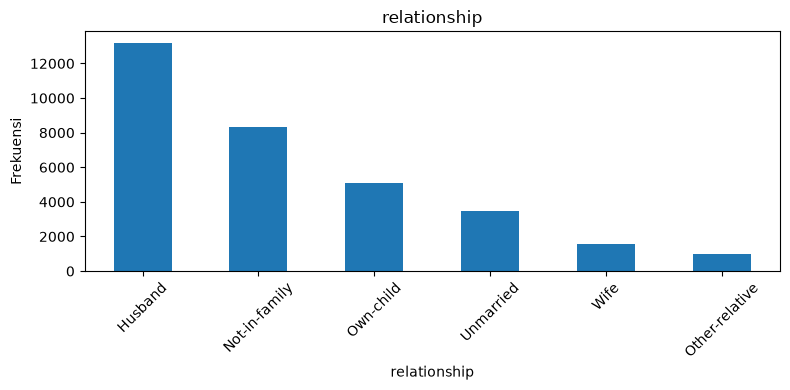

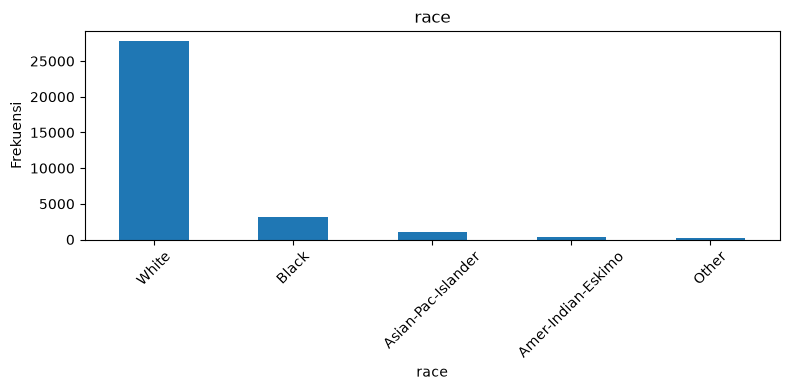

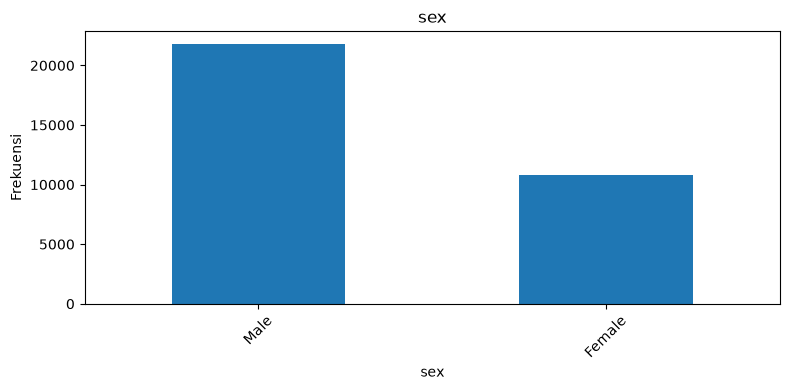

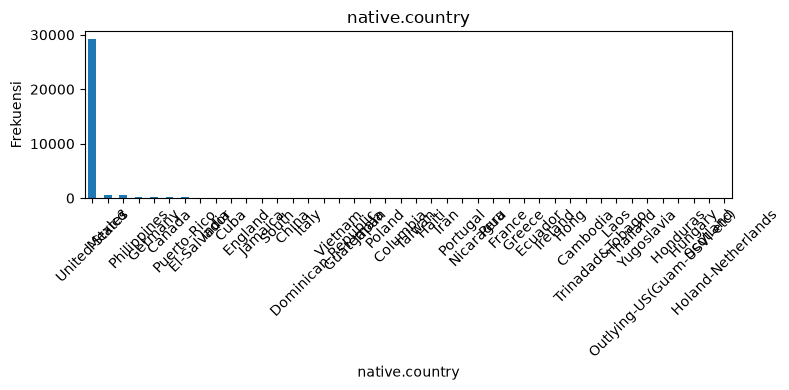

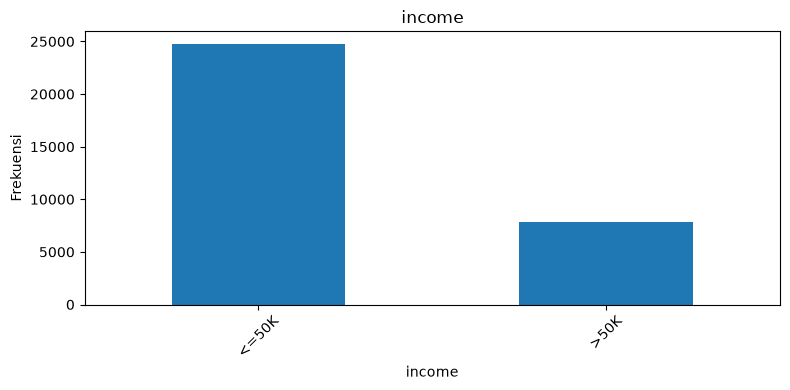

In [24]:
for col in categorical_cols:
    plt.figure(figsize=(8,4))
    df[col].value_counts().plot(kind='bar')
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Hasil Analisis Kolom Kategorikal

Berdasarkan distribusi frekuensi dan visualisasi bar chart, sebagian besar variabel kategorikal menunjukkan distribusi yang tidak merata.

- Workclas  didominasi oleh kategori Private.
- Education didominasi oleh kategori HS-grad.
- Marital.status didominasi oleh kategori Married-civ-spouse.
- Occupation didominasi oleh kategori Prof-specialty.
- Relationship didominasi oleh kategori Husband.
- Race didominasi oleh kategori White.
- Sex didominasi oleh kategori Male.
- Native.country sangat didominasi oleh kategori United-States, sedangkan kategori lainnya memiliki jumlah yang relatif sedikit.
- Income menunjukkan ketidakseimbangan kelas, di mana kategori <=50K memiliki jumlah yang lebih banyak dibandingkan >50K.

Secara keseluruhan, beberapa variabel kategorikal memiliki ketidakseimbangan distribusi yang cukup jelas. Temuan ini perlu diperhatikan pada tahap pemodelan karena dapat memengaruhi performa model, terutama pada variabel target income.

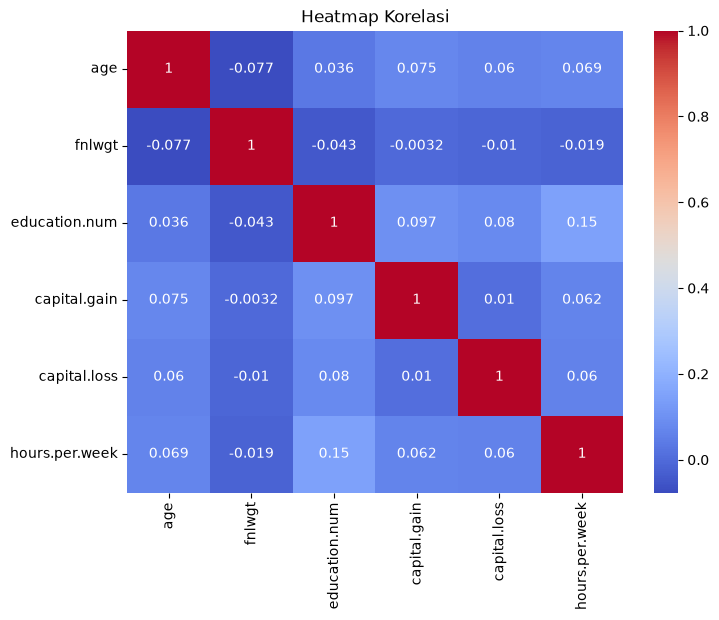

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Heatmap Korelasi')
plt.show()

## Heatmap Korelasi

Heatmap korelasi digunakan untuk melihat hubungan antar variabel numerik pada dataset. Berdasarkan hasil korelasi Pearson, sebagian besar variabel numerik memiliki nilai korelasi yang rendah.

Korelasi positif tertinggi ditemukan antara variabel **education.num** dan **hours.per.week** dengan nilai korelasi sebesar **0.146**, yang menunjukkan adanya hubungan positif yang sangat lemah. Korelasi positif tertinggi berikutnya terdapat pada hubungan **education.num** dan **capital.gain** sebesar **0.082**.

Secara keseluruhan, tidak terdapat hubungan linear yang kuat antar variabel numerik pada dataset.

In [26]:
corr = df.corr(numeric_only=True)

corr.unstack().sort_values(ascending=False)

age             age               1.000000
capital.loss    capital.loss      1.000000
education.num   education.num     1.000000
fnlwgt          fnlwgt            1.000000
hours.per.week  hours.per.week    1.000000
capital.gain    capital.gain      1.000000
education.num   hours.per.week    0.147241
hours.per.week  education.num     0.147241
capital.gain    education.num     0.096739
education.num   capital.gain      0.096739
capital.loss    education.num     0.079906
education.num   capital.loss      0.079906
age             capital.gain      0.074526
capital.gain    age               0.074526
age             hours.per.week    0.068869
hours.per.week  age               0.068869
capital.gain    hours.per.week    0.062302
hours.per.week  capital.gain      0.062302
                capital.loss      0.060100
capital.loss    hours.per.week    0.060100
age             capital.loss      0.059655
capital.loss    age               0.059655
education.num   age               0.036163
age        

## Analisis Korelasi Bivariat

Berdasarkan hasil korelasi antar variabel numerik, ditemukan dua pasangan variabel dengan nilai korelasi tertinggi, yaitu:

1. **education.num dan hours.per.week** dengan nilai korelasi sebesar **0.146**. Korelasi ini menunjukkan hubungan positif yang sangat lemah, sehingga individu dengan tingkat pendidikan lebih tinggi memiliki kecenderungan bekerja sedikit lebih lama per minggu.

2. **education.num dan capital.gain** dengan nilai korelasi sebesar **0.082**. Hubungan ini juga menunjukkan korelasi positif yang sangat lemah, yang berarti tingkat pendidikan memiliki hubungan kecil terhadap perolehan capital gain.

Secara keseluruhan, nilai korelasi antar variabel numerik tergolong rendah sehingga tidak ditemukan hubungan linear yang kuat antar fitur numerik.

In [27]:
import numpy as np

corr = df.corr(numeric_only=True)

corr_pairs = (
    corr.where(~np.eye(corr.shape[0], dtype=bool))
        .stack()
        .sort_values(ascending=False)
)

corr_pairs.head(10)

hours.per.week  education.num     0.147241
education.num   hours.per.week    0.147241
                capital.gain      0.096739
capital.gain    education.num     0.096739
capital.loss    education.num     0.079906
education.num   capital.loss      0.079906
age             capital.gain      0.074526
capital.gain    age               0.074526
hours.per.week  age               0.068869
age             hours.per.week    0.068869
dtype: float64

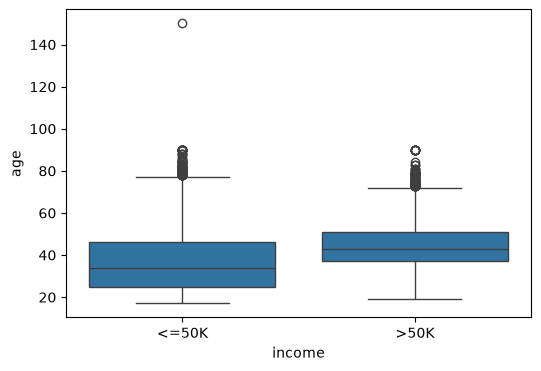

In [28]:
plt.figure(figsize=(6,4))
sns.boxplot(x='income', y='age', data=df)
plt.show()

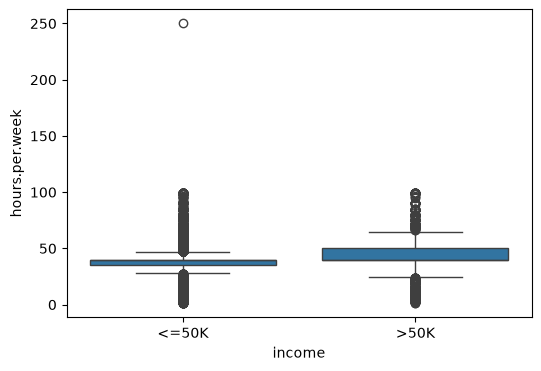

In [29]:
plt.figure(figsize=(6,4))
sns.boxplot(x='income', y='hours.per.week', data=df)
plt.show()

## Analisis Bivariat: Income terhadap Age dan Hours per Week

Boxplot digunakan untuk melihat perbedaan distribusi variabel numerik berdasarkan kategori income.

Pada hubungan **income dengan age**, kelompok pendapatan >50K memiliki median usia yang lebih tinggi dibandingkan kelompok <=50K. Hal ini menunjukkan bahwa individu dengan pendapatan lebih tinggi cenderung berada pada usia yang lebih matang, yang dapat berkaitan dengan pengalaman kerja.

Pada hubungan **income dengan hours.per.week**, kelompok >50K memiliki rata-rata jam kerja lebih tinggi dibandingkan kelompok <=50K. Hal ini menunjukkan adanya kecenderungan bahwa jam kerja yang lebih panjang dapat berhubungan dengan tingkat pendapatan yang lebih tinggi.

Selain itu, terdapat beberapa outlier pada kedua variabel, seperti usia ekstrem dan jumlah jam kerja yang sangat tinggi. Outlier tersebut perlu diperhatikan karena dapat memengaruhi hasil analisis dan pemodelan machine learning.

In [30]:
df = df.drop('employee_id', axis=1)

## Feature Engineering

Pada tahap feature engineering, dilakukan penghapusan fitur yang tidak relevan untuk analisis, yaitu kolom employee_id karena hanya berfungsi sebagai identitas unik dan tidak memberikan informasi terkait karakteristik individu.

Selain itu, dibuat fitur baru yaitu capital.total yang merupakan gabungan dari informasi capital.gain dan capital.loss untuk memberikan gambaran keseluruhan mengenai kondisi modal individu.

In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32571 entries, 0 to 32570
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             32571 non-null  float64 
 1   workclass       32571 non-null  category
 2   fnlwgt          32571 non-null  int64   
 3   education       32571 non-null  category
 4   education.num   32571 non-null  int64   
 5   marital.status  32571 non-null  category
 6   occupation      32571 non-null  category
 7   relationship    32571 non-null  category
 8   race            32571 non-null  category
 9   sex             32571 non-null  category
 10  capital.gain    32571 non-null  int64   
 11  capital.loss    32571 non-null  int64   
 12  hours.per.week  32571 non-null  int64   
 13  native.country  32571 non-null  category
 14  income          32571 non-null  category
dtypes: category(9), float64(1), int64(5)
memory usage: 1.8 MB


In [32]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

## Final Check dan Kesimpulan

Berdasarkan hasil pengecekan akhir menggunakan df.info() dan df.isnull().sum(), dataset telah berhasil melalui proses data cleaning. Dataset akhir terdiri dari 32.571 data dengan 15 fitur, seluruh kolom telah memiliki tipe data yang sesuai, dan tidak ditemukan adanya missing value.

Tahapan preprocessing yang telah dilakukan meliputi penghapusan data duplikat, perbaikan tipe data, penanganan missing value, serta feature engineering. Dengan kondisi data yang sudah bersih, dataset siap digunakan untuk tahap analisis lanjutan maupun pemodelan machine learning.

Karena variabel target income memiliki dua kategori (<=50K dan >50k), maka permasalahan ini termasuk dalam klasifikasi biner. Algoritma machine learning yang sesuai untuk dataset ini antara lain Logistic Regression, Decision Tree, Random Forest, dan Support Vector Machine (SVM).